# Modeling: Segment-Aware Targeting

Run after `feature_selection.ipynb`. Outputs → `outputs/segment_targeting/`.

GMM segments on `top_10`, per-cluster logistic on `top_03`, global top-k from OOF.


In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from cost_effective.models import SegmentConfig
from cost_effective.notebook_setup import setup_modeling_notebook
from cost_effective.notebook_workflows import (
    evaluate_topk_oof,
    export_segment_test_predictions,
    run_segment_targeting_pipeline,
    stage_matrices,
)
from cost_effective.paths import APPROACH_SEGMENT_TARGETING
from cost_effective.plots import plot_topk_oof_profit_curve

In [3]:
SEGMENT = SegmentConfig(
    n_clusters=5,
    segment_feature_set="top_10",
    model_feature_set="top_03",
    min_cluster_samples=80,
)

ctx = setup_modeling_notebook(APPROACH_SEGMENT_TARGETING)
_, y_train, x_test, x_stage2 = stage_matrices(ctx)

In [4]:
segment_result = run_segment_targeting_pipeline(ctx, SEGMENT)
segment_result.cluster_counts_train

{0: 685, 1: 1561, 2: 603, 3: 1524, 4: 627}

In [5]:
oof_eval = evaluate_topk_oof(
    y_train,
    segment_result.oof_probabilities,
    segment_result.feature_count,
    ctx.max_targets,
)
for line in oof_eval.summary_lines:
    print(line)
oof_eval.confusion_matrix

Business-optimal: k=998, threshold=0.5468, score=3380.00
F1-optimal: k=998, threshold=0.5468, f1=0.3431, roc_auc=0.5620, avg_precision=0.5622
Business curve TP=598, FP=400
F1 curve TP=598, FP=400
OOF profit-optimal k=998, break-even k=1000, effective k=998


,Predicted 0,Predicted 1
Actual 0,2112,400
Actual 1,1890,598


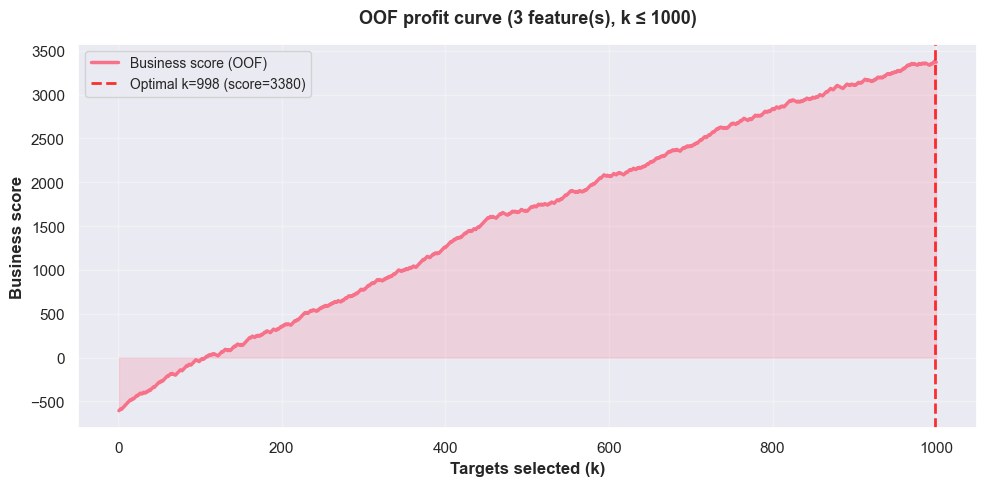

In [6]:
plot_topk_oof_profit_curve(
    oof_eval.business_curve,
    segment_result.feature_count,
    ctx.max_targets,
).show()

In [7]:
predictions = export_segment_test_predictions(
    ctx, segment_result, x_stage2, y_train, x_test, oof_eval, SEGMENT
)
predictions.head()

,rank,sample_index,probability
0,1,4134,0.820560
1,2,2916,0.780961
2,3,2855,0.761081
3,4,4928,0.758163
4,5,4912,0.756276
